# Практическое задание №6

Найдите любой временной ряд, содержащий не менее 100 значений и не менее 5 пропусков (если пропусков в исходном файле нет, можно удалить отдельные случайные значения самостоятельно). Выполните следующие задания:

| Variable     | Description                                                       |
| ------------ | ----------------------------------------------------------------- |
| **Data**     | The date of the record                                           |
| **Open**  | Opening price of the stock                                      |
| **High**  | Highest price of the stock for the day             |
| **Low** | Lowest price of the stock for the day              |
| **Close**  | Closing price of the stock                            |
| **Volume** | Number of shares traded                                      |

PS: Датосет содержит пропуски, удаленные самостоятельно

In [1]:
pip install pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 13.8 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.tsa.api as smt
from pmdarima.arima import auto_arima
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.metrics import mean_squared_error
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

1)	Постройте график, визуализирующий временной ряд. Охарактеризуйте его, присутствуют ли тренд, сезонность или цикл?

In [96]:
df = pd.read_csv('aapl_us_2025.csv')
df.head()

,Date,Open,High,Low,Close,Volume
0,1984-09-07,0.099824,0.101049,0.098619,0.099824,9.859472e+07
1,1984-09-10,0.099824,0.100130,0.097424,0.099232,7.652559e+07
2,1984-09-11,0.100130,0.102846,0.100130,0.101049,1.804519e+08
3,1984-09-12,0.101049,0.101641,0.098007,0.098007,1.576401e+08
4,1984-09-13,0.103460,0.103754,0.103460,0.103460,2.455186e+08


In [97]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10171 entries, 0 to 10170
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    10171 non-null  object 
 1   Open    10171 non-null  float64
 2   High    10142 non-null  float64
 3   Low     10171 non-null  float64
 4   Close   10171 non-null  float64
 5   Volume  10171 non-null  float64
dtypes: float64(5), object(1)
memory usage: 476.9+ KB


Временной ряд построим по 'High'

In [98]:
type(df['Date'][0])

str

In [99]:
df['Date'] = pd.to_datetime(df['Date'])
type(df['Date'][0])

pandas._libs.tslibs.timestamps.Timestamp

In [100]:
df.index = df['Date']
del df['Date']
df

,Open,High,Low,Close,Volume
Date,,,,,
1984-09-07,0.099824,0.101049,0.098619,0.099824,9.859472e+07
1984-09-10,0.099824,0.100130,0.097424,0.099232,7.652559e+07
1984-09-11,0.100130,0.102846,0.100130,0.101049,1.804519e+08
1984-09-12,0.101049,0.101641,0.098007,0.098007,1.576401e+08
1984-09-13,0.103460,0.103754,0.103460,0.103460,2.455186e+08
...,...,...,...,...,...
2025-01-13,233.530000,234.670000,229.720000,234.400000,4.963072e+07
2025-01-14,234.750000,236.120000,232.472000,233.280000,3.943529e+07
2025-01-15,234.635000,238.960000,234.430000,237.870000,3.983197e+07


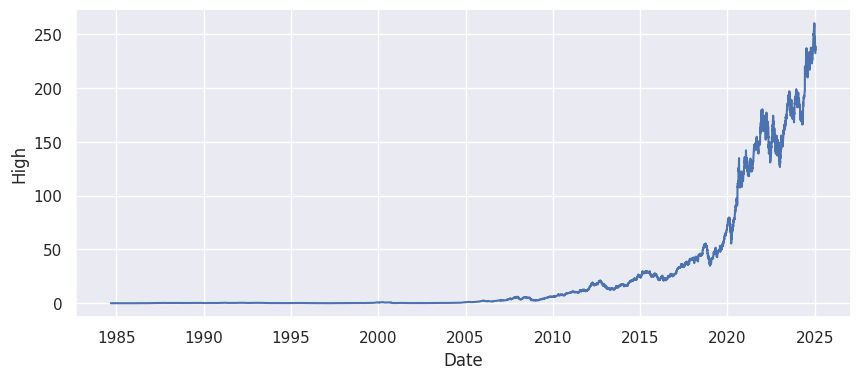

In [101]:
plt.figure(figsize=(10, 4))
sns.lineplot(data=df, x=df.index, y=df['High'])
plt.ylabel('High');

По графику видно, что присутсвует тренд. Циклов и сезонности нет.

2)	Восстановите пропущенные значения. Обоснуйте и опишите метод, который Вы будете использовать для восстановления пропущенных значений.

In [102]:
# Ищем пропущенные значения
dates_with_nan = df[df['High'].isna()].index
df.loc[dates_with_nan]

,Open,High,Low,Close,Volume
Date,,,,,
2004-07-13,0.440917,NaN,0.437616,0.440559,3.744014e+08
2004-07-14,0.436669,NaN,0.433399,0.446062,9.905336e+08
2004-07-15,0.490684,NaN,0.484097,0.496403,2.093278e+09
2004-07-16,0.496403,NaN,0.484333,0.485569,5.780211e+08
2004-07-19,0.483138,NaN,0.477370,0.481914,6.314214e+08
2004-07-20,0.481301,NaN,0.475929,0.485569,3.833675e+08
2004-07-21,0.487069,NaN,0.472649,0.476807,3.567329e+08
2004-07-22,0.472649,NaN,0.468373,0.477746,3.956520e+08
2004-07-23,0.478042,NaN,0.459681,0.462922,3.239490e+08


Восстанавливаем пропущенные значения методом интерполяции, так как цены на акции изменяются довольно плавно в короткие промежутки времени, в нашем случае максимум 3 дня. Также, используя интерполяцию, тренд сохранится.

In [103]:
df1= df.interpolate();
df1.loc[dates_with_nan]

,Open,High,Low,Close,Volume
Date,,,,,
2004-07-13,0.440917,0.453666,0.437616,0.440559,3.744014e+08
2004-07-14,0.436669,0.454278,0.433399,0.446062,9.905336e+08
2004-07-15,0.490684,0.454890,0.484097,0.496403,2.093278e+09
2004-07-16,0.496403,0.455502,0.484333,0.485569,5.780211e+08
2004-07-19,0.483138,0.456114,0.477370,0.481914,6.314214e+08
2004-07-20,0.481301,0.456726,0.475929,0.485569,3.833675e+08
2004-07-21,0.487069,0.457338,0.472649,0.476807,3.567329e+08
2004-07-22,0.472649,0.457951,0.468373,0.477746,3.956520e+08
2004-07-23,0.478042,0.458563,0.459681,0.462922,3.239490e+08


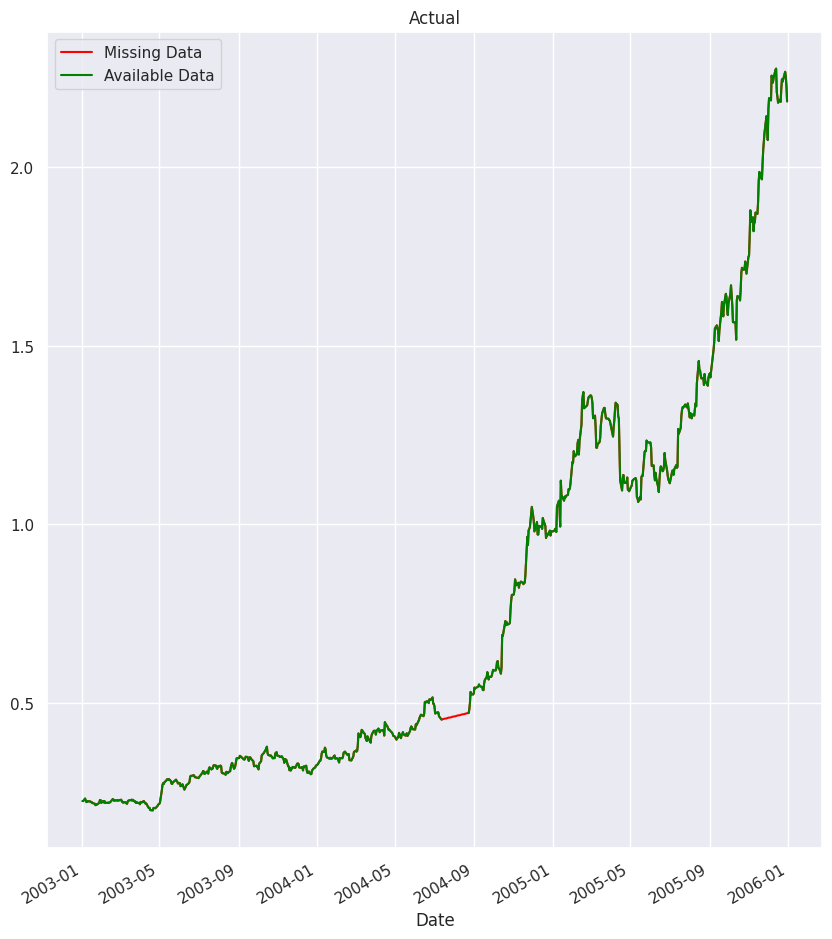

In [104]:
fig, axes = plt.subplots(1, 1, figsize=(10, 12))

df1['2003-01-01':'2006-01-01']['High'].plot(title='Actual', ax=axes, label='Actual', color='red')
df['2003-01-01':'2006-01-01']['High'].plot(title='Actual', ax=axes, label='Actual', color='green')
axes.legend(["Missing Data", "Available Data"])

    3)	Преобразуйте временной ряд к стационарному виду. Обоснуйте и опишите методы, которые Вы использовали. Приведите график и результаты статистических тестов, подтверждающих, что ряд стал стационарным.

Воспользуемся тестом Дики-Фуллера для проверки ряда на стационраность.

In [105]:
from statsmodels.tsa.stattools import adfuller
adft = adfuller(df1['High'])

In [106]:
print('p-value: ', adft[1])

p-value:  1.0


Вывод: ряд не является стационарным (p > 0.05). Это закономерно, поскольку в нём присутствуют явный тренд.

In [107]:
df1['High_dif1'] = df1['High'] - df1['High'].shift(1)
adft = adfuller(df1['High_dif1'].dropna(),autolag="AIC")
print('p-value: ', adft[1])

p-value:  2.990591206741167e-30


Однократно дифференцированный ряд стал стационарным.

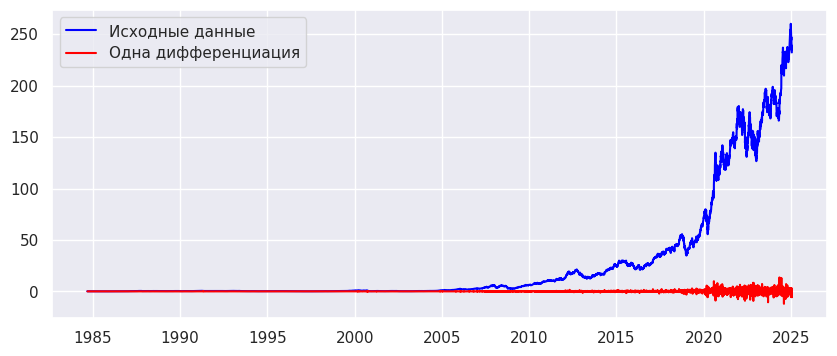

In [109]:
plt.figure(figsize=(10, 4))
plt.plot(df1['High'], color="blue",label="Исходные данные")
plt.plot(df1['High_dif1'], color="red", label="Одна дифференциация")
plt.legend(loc="best")

4)	Постройте и опишите коррелограммы (графики автокорреляционной функции и частной автокорреляционной функции) для временного ряда.

In [110]:
autocorrelation_lag1 = df1['High_dif1'].autocorr(lag=1)
print("One Day Lag: ", autocorrelation_lag1)

One Day Lag:  0.10934187912036872


Слабоположительная автокорреляция.

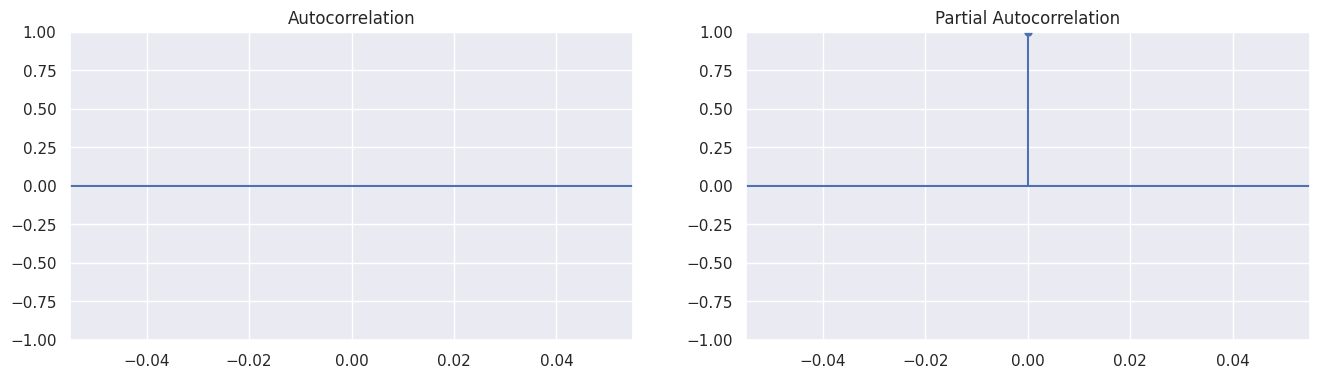

In [111]:
fig, axes = plt.subplots(1,2,figsize=(16,4),dpi=100)
plot_acf(df1['High_dif1'], lags=100, ax=axes[0])
plot_pacf(df1['High_dif1'], lags=100, ax=axes[1])
plt.show()

По графикам видну, что изменения цены непредсказуемы по прошлым данным.

 5)	Разбейте выборку на обучающую и тестовую (обоснуйте выбор временного интервала для тестовой выборки). На основе обучающей выборки идентифицируйте параметры модели SARIMA. Какие параметры модели p, d и q Вы будете использовать и почему? Оцените качество модели. Насколько хорошо она предсказывает значения тестовой выборки?

In [112]:
df = df.ffill()
df['High'] = df['High'].astype(float)
df

,Open,High,Low,Close,Volume
Date,,,,,
1984-09-07,0.099824,0.101049,0.098619,0.099824,9.859472e+07
1984-09-10,0.099824,0.100130,0.097424,0.099232,7.652559e+07
1984-09-11,0.100130,0.102846,0.100130,0.101049,1.804519e+08
1984-09-12,0.101049,0.101641,0.098007,0.098007,1.576401e+08
1984-09-13,0.103460,0.103754,0.103460,0.103460,2.455186e+08
...,...,...,...,...,...
2025-01-13,233.530000,234.670000,229.720000,234.400000,4.963072e+07
2025-01-14,234.750000,236.120000,232.472000,233.280000,3.943529e+07
2025-01-15,234.635000,238.960000,234.430000,237.870000,3.983197e+07


Тестовая выборка осущетсвляется на датах от 2024 года до 2025 года, так как по графику видно, что произошел резкий скачек вверх, после снижения. Интересно сможет ли это спрогнозировать модель.

In [113]:
df['Date'] = df.index
train = df[df['Date'] < "2024-01-01"]
del train['Date']
train

,Open,High,Low,Close,Volume
Date,,,,,
1984-09-07,0.099824,0.101049,0.098619,0.099824,9.859472e+07
1984-09-10,0.099824,0.100130,0.097424,0.099232,7.652559e+07
1984-09-11,0.100130,0.102846,0.100130,0.101049,1.804519e+08
1984-09-12,0.101049,0.101641,0.098007,0.098007,1.576401e+08
1984-09-13,0.103460,0.103754,0.103460,0.103460,2.455186e+08
...,...,...,...,...,...
2023-12-22,194.442000,194.672000,192.240000,192.868000,3.729054e+07
2023-12-26,192.878000,193.157000,192.101000,192.320000,2.902905e+07
2023-12-27,191.763000,192.768000,190.367000,192.420000,4.827016e+07


In [114]:
test = df[df['Date'] >= "2024-01-01"]
del test['Date']
test

,Open,High,Low,Close,Volume
Date,,,,,
2024-01-02,186.442,187.728,183.190,184.938,8.280169e+07
2024-01-03,183.524,185.178,182.736,183.554,5.863612e+07
2024-01-04,181.462,182.395,180.195,181.222,7.225672e+07
2024-01-05,181.302,182.069,179.488,180.495,6.261637e+07
2024-01-08,181.397,184.898,180.814,184.859,5.936890e+07
...,...,...,...,...,...
2025-01-13,233.530,234.670,229.720,234.400,4.963072e+07
2025-01-14,234.750,236.120,232.472,233.280,3.943529e+07
2025-01-15,234.635,238.960,234.430,237.870,3.983197e+07


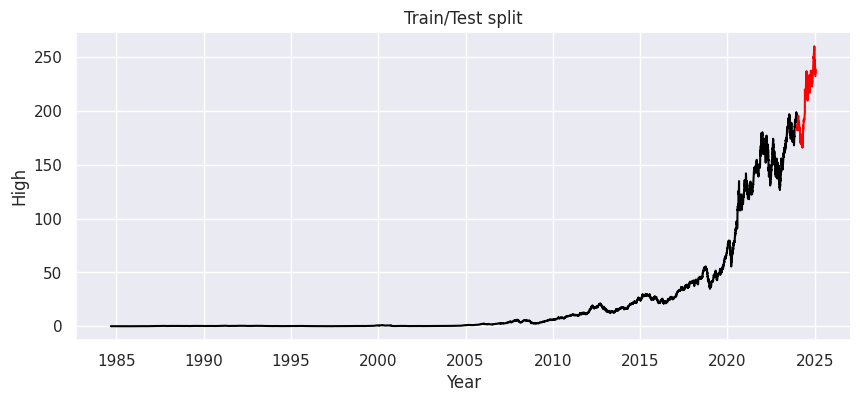

In [115]:
plt.figure(figsize=(10, 4))
plt.plot(train['High'], color = "black")
plt.plot(test['High'], color = "red")
plt.title("Train/Test split")
plt.ylabel("High")
plt.xlabel('Year')
sns.set()
plt.show()

In [90]:
auto_model = auto_arima(train['High'],
                        seasonal=True,
                        m=5, # 5 рабочих дней
                        trace=True,
                        error_action='ignore',
                        suppress_warnings=True,
                        stepwise=True)

Performing stepwise search to minimize aic
 ARIMA(2,2,2)(1,0,1)[5]             : AIC=inf, Time=14.54 sec
 ARIMA(0,2,0)(0,0,0)[5]             : AIC=28572.871, Time=0.20 sec
 ARIMA(1,2,0)(1,0,0)[5]             : AIC=26411.464, Time=1.31 sec
 ARIMA(0,2,1)(0,0,1)[5]             : AIC=inf, Time=4.22 sec
 ARIMA(1,2,0)(0,0,0)[5]             : AIC=26471.423, Time=0.45 sec
 ARIMA(1,2,0)(2,0,0)[5]             : AIC=26413.179, Time=2.32 sec
 ARIMA(1,2,0)(1,0,1)[5]             : AIC=26413.280, Time=3.65 sec
 ARIMA(1,2,0)(0,0,1)[5]             : AIC=26412.711, Time=1.24 sec
 ARIMA(1,2,0)(2,0,1)[5]             : AIC=26413.205, Time=9.46 sec
 ARIMA(0,2,0)(1,0,0)[5]             : AIC=28507.261, Time=1.25 sec
 ARIMA(2,2,0)(1,0,0)[5]             : AIC=25326.458, Time=1.83 sec
 ARIMA(2,2,0)(0,0,0)[5]             : AIC=25382.350, Time=0.71 sec
 ARIMA(2,2,0)(2,0,0)[5]             : AIC=25327.339, Time=2.49 sec
 ARIMA(2,2,0)(1,0,1)[5]             : AIC=25327.771, Time=4.76 sec
 ARIMA(2,2,0)(0,0,1)[5]       

По результам модели p = 3, d = 2, q = 0.

In [ ]:
model = SARIMAX(train['High'],
                order=auto_model.order,
                seasonal_order=auto_model.seasonal_order,
                enforce_stationarity=False,
                enforce_invertibility=False)

results = model.fit(disp=False)
print(results.summary())

                                       SARIMAX Results                                        
Dep. Variable:                                   High   No. Observations:                 9908
Model:             SARIMAX(3, 2, 0)x(1, 0, [1, 2], 5)   Log Likelihood              -12341.379
Date:                                Tue, 10 Feb 2026   AIC                          24696.757
Time:                                        15:07:05   BIC                          24747.156
Sample:                                             0   HQIC                         24713.826
                                               - 9908                                         
Covariance Type:                                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.6572      0.003   -223.159      0.000      -0.663      -0.651
ar.

Модель имеет проблему с остатками (Ljung-Box (L1) (Q): 25.80, Prob(Q): 0.00), а занчит прогнозы менее будут менее точными.

In [ ]:
forecast = results.get_forecast(steps=len(test['High']))
forecast_mean = forecast.predicted_mean
conf_int = forecast.conf_int()
forecast_mean.index = test.index
conf_int.index = test.index

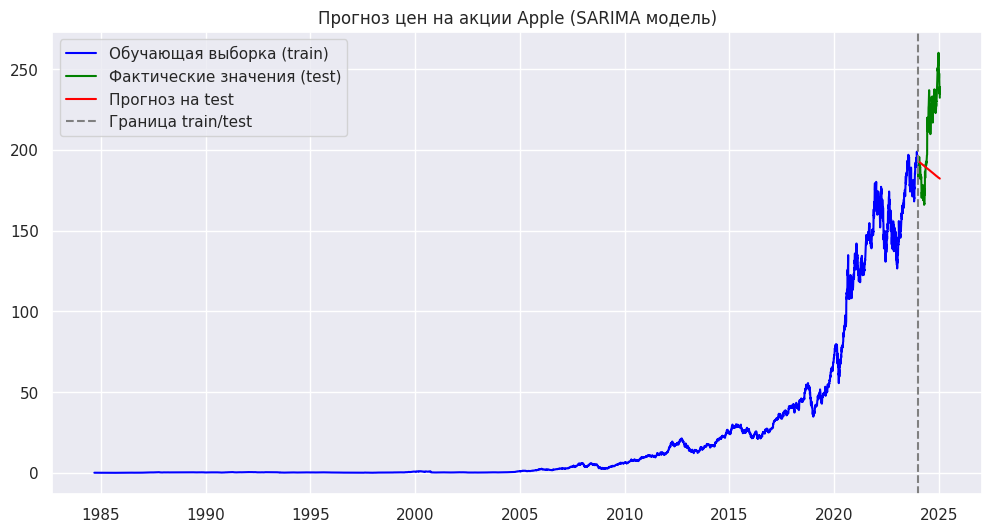

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(train['High'], label='Обучающая выборка (train)', color='blue')
plt.plot(test['High'], label='Фактические значения (test)', color='green')
plt.plot(forecast_mean, label='Прогноз на test', color='red')
plt.axvline(pd.Timestamp("2024-01-01"), color='gray', linestyle='--', label='Граница train/test')
plt.title('Прогноз цен на акции Apple (SARIMA модель)')
plt.legend()
plt.show()

Что и ожидалось, прогноз поолучился неточным. Модель успешно спрогнозировала понижение цены в начале 2024, но в оригинале понижение более ризкое, а также не предугадала дальнейшее повышение.

In [ ]:
def regression_quality_metrics_report(y_true, y_pred):

    rmse = np.sqrt( mean_squared_error(y_true, y_pred) )
    mae = mean_absolute_error(y_true, y_pred)
    rse = np.sqrt( ( (y_true - y_pred)**2 ).sum() / ( (y_true - y_true.mean())**2 ).sum() )
    rae = np.abs( y_true - y_pred ).sum() / np.abs( y_true - y_true.mean() ).sum()
    mape = 100. / len(y_true) * np.abs( 1. - y_pred/y_true ).sum()


    return [rmse, mae, rse, rae, mape]

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [ ]:
metrics_report = pd.DataFrame(columns=['RMSE', 'MAE', 'RSE', 'RAE', 'MAPE'])
metrics_report.loc['SARIMAX'] = regression_quality_metrics_report(test['High'].values, forecast_mean.values)
metrics_report

,RMSE,MAE,RSE,RAE,MAPE
SARIMAX,36.505632,30.462389,1.403326,1.287315,13.685813


Модель получилась неудачной. По таблице она больше подходит для краткосрочного прогнозирования (1-2 месяца) с приемлемой точностью 13.7%.

 6)	Используя модель SARIMA, постройте прогноз временного ряда на 30 периодов вперёд. Как Вы считаете, насколько реалистичный получился прогноз?

In [91]:
model = SARIMAX(df['High'],
                order=auto_model.order,
                seasonal_order=auto_model.seasonal_order,
                enforce_stationarity=False,
                enforce_invertibility=False)

results = model.fit(disp=False)
print(results.summary())

                                       SARIMAX Results                                        
Dep. Variable:                                   High   No. Observations:                10171
Model:             SARIMAX(3, 2, 0)x(1, 0, [1, 2], 5)   Log Likelihood              -14122.385
Date:                                Tue, 10 Feb 2026   AIC                          28258.771
Time:                                        20:02:35   BIC                          28309.353
Sample:                                             0   HQIC                         28275.879
                                              - 10171                                         
Covariance Type:                                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.6332      0.003   -214.253      0.000      -0.639      -0.627
ar.

In [93]:
forecast = results.get_forecast(steps=30)
forecast_mean = forecast.predicted_mean
conf_int = forecast.conf_int()

In [94]:
last_date = df.index[-1]
future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1),
                             periods=30,
                             freq='D')
forecast_mean.index = future_dates
conf_int.index = future_dates

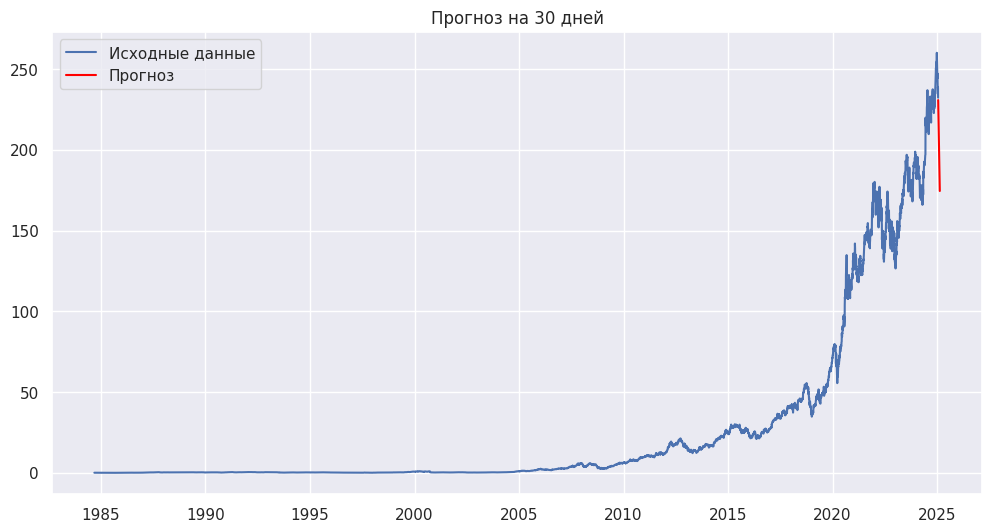

In [95]:
plt.figure(figsize=(12,6))
plt.plot(df['High'], label='Исходные данные')
plt.plot(forecast_mean, label='Прогноз', color='red')
plt.title('Прогноз на 30 дней')
plt.legend()
plt.show()

Мне кажется, что этот прогноз не реалистичен: из плюсов после 2025 года действительно кажется, что будет понижение, но во превых не такой длительный и с колебаниями, во втрорых потом должен быть резкий рост. Более этого модель нарушает тренд. Как говорилось ранее, модель может неплохо спрогнозировать очень краткосрочные периоды, судя по эксперементу, возможно макисмум неделя.

Обратите внимание, что все пункты задания должны сопровождаться _выполненным_ фрагментом кода!

### Этот файл нужно сохранить как Jupyter Notebook (.ipynb) и загрузить в Smart LMS до 23:55 10 февраля.

- При сдаче работы до 23:55 11 февраля вычитается 1 балл из итоговой оценки.
- При сдаче работы до 23:55 12 февраля вычитаются 2 балла из итоговой оценки.
- После **23:55 12 февраля** работа не принимается.